# 04 — LSTM Time-Series Forecasting

## Rossmann Sales Forecasting — Project 6

This notebook covers the deep-learning time-series stage: daily aggregation, stationarity testing, ACF/PACF analysis, sliding-window preparation, scaling, a univariate LSTM baseline, an improved multivariate LSTM, validation, comparison plots, and timestamped serialization.

**Execution note:** Completed training outputs are preserved. LSTM training is computationally expensive, so do not retrain merely to reproduce the documented results.

## Time-Series Setup


## Standalone Data Setup

This notebook is separate from Notebook 1, so it rebuilds the merged `df` required for time-series analysis from the project datasets.

The multivariate LSTM uses daily total `Sales`, daily number of open stores (`OpenStores`), and `DayOfWeek`. Validation is July 2015.

In [ ]:
import pandas as pd

train = pd.read_csv('../train.csv')
store = pd.read_csv('../store.csv')

train['Date'] = pd.to_datetime(train['Date'])
train['StateHoliday'] = train['StateHoliday'].astype(str)

merged = train.merge(store, on='Store', how='left')
df = merged.copy()

print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("Merged working dataset shape:", df.shape)
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

In [ ]:
import pandas as pd

# Load datasets
train = pd.read_csv('/content/train.csv')
store = pd.read_csv('/content/store.csv')
test = pd.read_csv('../test.csv')
sample_submission = pd.read_csv('../sample_submission.csv')

print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

/tmp/ipykernel_675/921756995.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/content/train.csv')


Train shape: (1017209, 9)
Store shape: (1115, 10)
Test shape: (41088, 8)
Sample submission shape: (41088, 2)


In [ ]:
test = pd.read_csv('../test.csv')
sample_submission = pd.read_csv('../sample_submission.csv')

print("TEST SHAPE:", test.shape)
print("TEST COLUMNS:")
print(test.columns.tolist())

print("\nTEST DATA TYPES:")
print(test.dtypes)

print("\nTEST MISSING VALUES:")
print(test.isnull().sum())

print("\nSAMPLE SUBMISSION SHAPE:", sample_submission.shape)
print("SAMPLE SUBMISSION COLUMNS:")
print(sample_submission.columns.tolist())

print("\nSAMPLE SUBMISSION FIRST 5 ROWS:")
print(sample_submission.head())

TEST SHAPE: (41088, 8)
TEST COLUMNS:
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

TEST DATA TYPES:
Id                 int64
Store              int64
DayOfWeek          int64
Date              object
Open             float64
Promo              int64
StateHoliday      object
SchoolHoliday      int64
dtype: object

TEST MISSING VALUES:
Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

SAMPLE SUBMISSION SHAPE: (41088, 2)
SAMPLE SUBMISSION COLUMNS:
['Id', 'Sales']

SAMPLE SUBMISSION FIRST 5 ROWS:
   Id  Sales
0   1      0
1   2      0
2   3      0
3   4      0
4   5      0


In [ ]:
# Convert dates
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

# Standardize StateHoliday data type
train['StateHoliday'] = train['StateHoliday'].astype(str)
test['StateHoliday'] = test['StateHoliday'].astype(str)

# Feature engineering for TRAIN
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day
train['WeekOfYear'] = train['Date'].dt.isocalendar().week.astype(int)
train['IsWeekend'] = train['DayOfWeek'].isin([6, 7]).astype(int)
train['YearMonth'] = train['Date'].dt.to_period('M').astype(str)

# Feature engineering for TEST
test['Year'] = test['Date'].dt.year
test['Month'] = test['Date'].dt.month
test['Day'] = test['Date'].dt.day
test['WeekOfYear'] = test['Date'].dt.isocalendar().week.astype(int)
test['IsWeekend'] = test['DayOfWeek'].isin([6, 7]).astype(int)
test['YearMonth'] = test['Date'].dt.to_period('M').astype(str)

# Merge train with store information
merged = train.merge(store, on='Store', how='left')

# Create working dataframe
df = merged.copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Merged shape:", merged.shape)
print("DF shape:", df.shape)

print("\nMissing StoreType after merge:", df['StoreType'].isnull().sum())
print("Missing Assortment after merge:", df['Assortment'].isnull().sum())

Train shape: (1017209, 15)
Test shape: (41088, 14)
Merged shape: (1017209, 24)
DF shape: (1017209, 24)

Missing StoreType after merge: 0
Missing Assortment after merge: 0


## Daily Sales Time Series


In [ ]:
# Create daily total Sales time series

daily_sales = (
    df.groupby('Date', as_index=False)['Sales']
      .sum()
      .sort_values('Date')
)

print("Daily Sales shape:", daily_sales.shape)

print("\nDate range:")
print(daily_sales['Date'].min(), "to", daily_sales['Date'].max())

print("\nFirst 10 rows:")
print(daily_sales.head(10))

print("\nLast 10 rows:")
print(daily_sales.tail(10))

Daily Sales shape: (942, 2)

Date range:
2013-01-01 00:00:00 to 2015-07-31 00:00:00

First 10 rows:
        Date     Sales
0 2013-01-01     97235
1 2013-01-02   6949829
2 2013-01-03   6347820
3 2013-01-04   6638954
4 2013-01-05   5951593
5 2013-01-06    143904
6 2013-01-07  10826848
7 2013-01-08   8749437
8 2013-01-09   7746603
9 2013-01-10   7751485

Last 10 rows:
          Date     Sales
932 2015-07-22   6110388
933 2015-07-23   6687068
934 2015-07-24   6601325
935 2015-07-25   6021666
936 2015-07-26    285865
937 2015-07-27  10707292
938 2015-07-28   9115073
939 2015-07-29   8499962
940 2015-07-30   8798854
941 2015-07-31  10109742


## Stationarity — ADF Test


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Extract the Sales time series
sales_series = daily_sales['Sales']

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(sales_series)

adf_statistic = adf_result[0]
p_value = adf_result[1]

print("Augmented Dickey-Fuller Test")
print("----------------------------")
print("ADF Statistic:", round(adf_statistic, 4))
print("p-value:", round(p_value, 6))

print("\nInterpretation:")

if p_value <= 0.05:
    print("The series is likely stationary (p-value <= 0.05).")
else:
    print("The series is likely non-stationary (p-value > 0.05).")

Augmented Dickey-Fuller Test
----------------------------
ADF Statistic: -4.7616
p-value: 6.4e-05

Interpretation:
The series is likely stationary (p-value <= 0.05).


### Time-Series Structure Decision

The ADF test produced a statistic of approximately **-4.7616** with a p-value of approximately **6.4e-05**. Because the p-value is below 0.05, the unit-root null hypothesis is rejected and the series is treated as stationary for this project.

Therefore, **first-order differencing was not required**. The ACF/PACF plots show strong weekly structure around lags 7, 14, 21 and 28. A 28-day sliding window was selected to capture approximately four weekly cycles.

## Autocorrelation Analysis — ACF/PACF


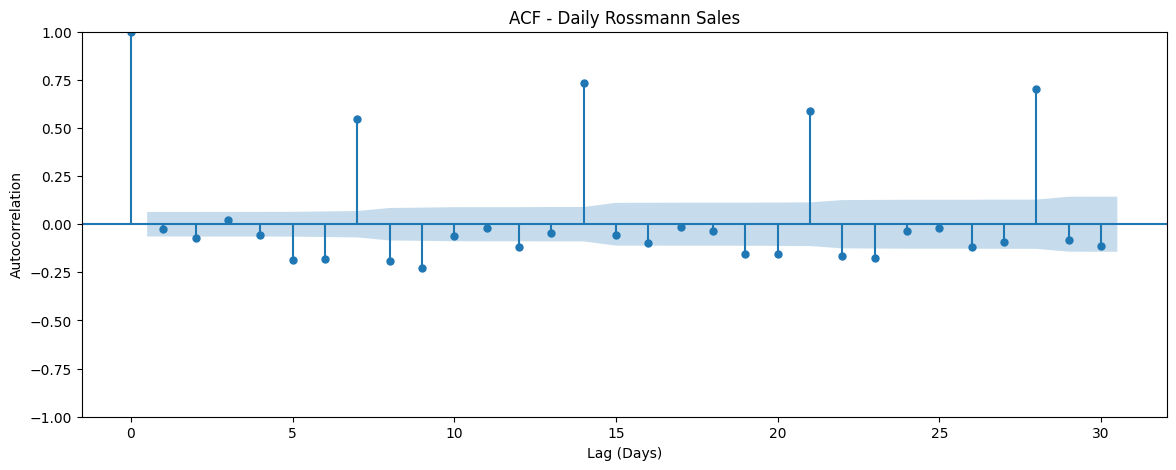

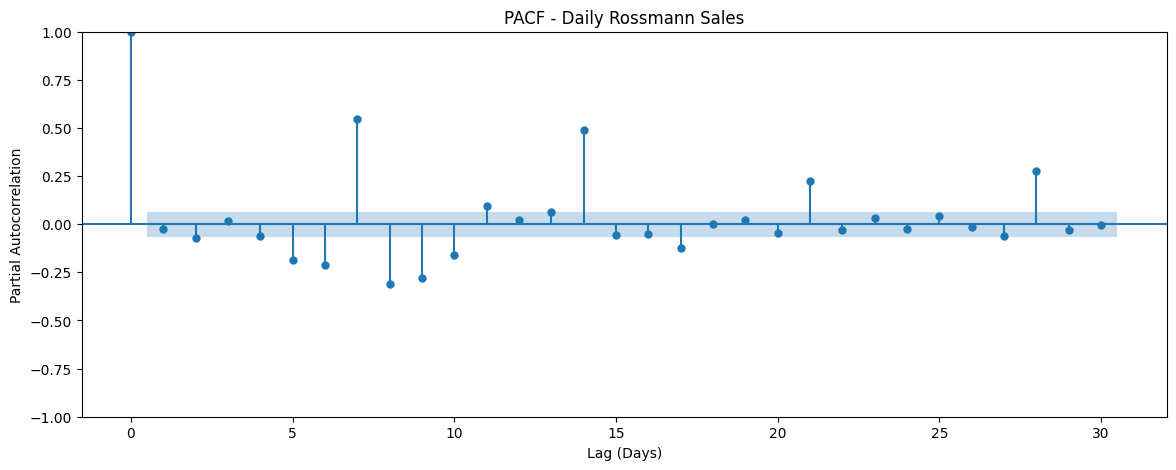

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Create ACF and PACF plots
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    sales_series,
    lags=30,
    ax=ax
)

plt.title("ACF - Daily Rossmann Sales")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))

plot_pacf(
    sales_series,
    lags=30,
    ax=ax,
    method='ywm'
)

plt.title("PACF - Daily Rossmann Sales")
plt.xlabel("Lag (Days)")
plt.ylabel("Partial Autocorrelation")
plt.show()

## Univariate LSTM Data Preparation


In [ ]:
import numpy as np

# Use daily total Sales for the LSTM
daily_sales_values = daily_sales['Sales'].values.astype('float32')

# 28-day sliding window
window_size = 28

# Split the time series chronologically
train_daily = daily_sales[
    daily_sales['Date'] < '2015-07-01'
].copy()

validation_daily = daily_sales[
    daily_sales['Date'] >= '2015-07-01'
].copy()

print("Training days:", len(train_daily))
print("Validation days:", len(validation_daily))


# Function to create sliding-window sequences
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)


# Create training sequences
X_lstm_train, y_lstm_train = create_sequences(
    train_daily['Sales'].values.astype('float32'),
    window_size
)


# For validation, include the last 28 training days
# so the first July prediction has the required historical context.
validation_input = np.concatenate([
    train_daily['Sales'].values[-window_size:].astype('float32'),
    validation_daily['Sales'].values.astype('float32')
])

X_lstm_val, y_lstm_val = create_sequences(
    validation_input,
    window_size
)

print("\nSequence shapes:")
print("X_lstm_train:", X_lstm_train.shape)
print("y_lstm_train:", y_lstm_train.shape)
print("X_lstm_val:", X_lstm_val.shape)
print("y_lstm_val:", y_lstm_val.shape)

Training days: 911
Validation days: 31

Sequence shapes:
X_lstm_train: (883, 28)
y_lstm_train: (883,)
X_lstm_val: (31, 28)
y_lstm_val: (31,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create the scaler
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit ONLY on training Sales data
train_sales_for_scaling = train_daily['Sales'].values.reshape(-1, 1)

scaler.fit(train_sales_for_scaling)

# Scale training sequences
X_lstm_train_scaled = scaler.transform(
    X_lstm_train.reshape(-1, 1)
).reshape(X_lstm_train.shape)

y_lstm_train_scaled = scaler.transform(
    y_lstm_train.reshape(-1, 1)
).reshape(-1)

# Scale validation sequences
X_lstm_val_scaled = scaler.transform(
    X_lstm_val.reshape(-1, 1)
).reshape(X_lstm_val.shape)

y_lstm_val_scaled = scaler.transform(
    y_lstm_val.reshape(-1, 1)
).reshape(-1)

print("Scaled training X shape:", X_lstm_train_scaled.shape)
print("Scaled training y shape:", y_lstm_train_scaled.shape)
print("Scaled validation X shape:", X_lstm_val_scaled.shape)
print("Scaled validation y shape:", y_lstm_val_scaled.shape)

print("\nTraining X scaled range:",
      X_lstm_train_scaled.min(),
      "to",
      X_lstm_train_scaled.max())

print("Training y scaled range:",
      y_lstm_train_scaled.min(),
      "to",
      y_lstm_train_scaled.max())

Scaled training X shape: (883, 28)
Scaled training y shape: (883,)
Scaled validation X shape: (31, 28)
Scaled validation y shape: (31,)

Training X scaled range: -1.0 to 0.9999999
Training y scaled range: -0.9973113 to 0.9999999


In [ ]:
# Reshape data for LSTM
# LSTM expects: (samples, time_steps, features)

X_lstm_train_reshaped = X_lstm_train_scaled.reshape(
    X_lstm_train_scaled.shape[0],
    X_lstm_train_scaled.shape[1],
    1
)

X_lstm_val_reshaped = X_lstm_val_scaled.reshape(
    X_lstm_val_scaled.shape[0],
    X_lstm_val_scaled.shape[1],
    1
)

print("Training input shape:", X_lstm_train_reshaped.shape)
print("Validation input shape:", X_lstm_val_reshaped.shape)
print("Training target shape:", y_lstm_train_scaled.shape)
print("Validation target shape:", y_lstm_val_scaled.shape)

Training input shape: (883, 28, 1)
Validation input shape: (31, 28, 1)
Training target shape: (883,)
Validation target shape: (31,)


## Univariate LSTM Architecture


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# Build LSTM model using the recommended Keras Input layer
lstm_model = Sequential([
    Input(shape=(28, 1)),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

# Display model architecture
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

## Univariate LSTM Training & Evaluation


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to reduce overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the LSTM
history = lstm_model.fit(
    X_lstm_train_reshaped,
    y_lstm_train_scaled,
    validation_data=(
        X_lstm_val_reshaped,
        y_lstm_val_scaled
    ),
    epochs=30,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1723 - val_loss: 0.1400
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1652 - val_loss: 0.1361
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1638 - val_loss: 0.1362
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1621 - val_loss: 0.1379
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1578 - val_loss: 0.1248
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1539 - val_loss: 0.1221
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1568 - val_loss: 0.1245
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1539 - val_loss: 0.1202
Epoch 9/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1514 - val_loss: 0.1158
Epoch 10/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1510 - val_loss: 0.1148
Epoch 11/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1485 - val_loss: 0.1107
Epoch 12/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1

In [ ]:
print("Epochs completed:", len(history.history['loss']))
print("Best validation loss:", min(history.history['val_loss']))
print("Best epoch:", history.history['val_loss'].index(
    min(history.history['val_loss'])
) + 1)

Epochs completed: 22
Best validation loss: 0.07411712408065796
Best epoch: 17


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on validation data
lstm_val_predictions_scaled = lstm_model.predict(
    X_lstm_val_reshaped,
    verbose=0
)

# Convert predictions back to original Sales scale
lstm_val_predictions = scaler.inverse_transform(
    lstm_val_predictions_scaled
).flatten()

# Convert actual validation targets back to original Sales scale
lstm_val_actual = scaler.inverse_transform(
    y_lstm_val_scaled.reshape(-1, 1)
).flatten()

# Calculate evaluation metrics
lstm_mae = mean_absolute_error(
    lstm_val_actual,
    lstm_val_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_val_actual,
        lstm_val_predictions
    )
)

lstm_r2 = r2_score(
    lstm_val_actual,
    lstm_val_predictions
)

print("LSTM Validation Results")
print("-----------------------")
print(f"MAE  : {lstm_mae:.2f}")
print(f"RMSE : {lstm_rmse:.2f}")
print(f"R²   : {lstm_r2:.4f}")

LSTM Validation Results
-----------------------
MAE  : 1469127.12
RMSE : 2113477.58
R²   : 0.4518


In [ ]:
# Compare actual and predicted Sales
lstm_comparison = pd.DataFrame({
    'Date': validation_daily['Date'].values,
    'Actual_Sales': lstm_val_actual,
    'Predicted_Sales': lstm_val_predictions
})

# Calculate prediction error
lstm_comparison['Error'] = (
    lstm_comparison['Predicted_Sales']
    - lstm_comparison['Actual_Sales']
)

# Display first 15 validation predictions
print(lstm_comparison.head(15).to_string(index=False))

print("\nAverage Actual Sales:",
      f"{lstm_comparison['Actual_Sales'].mean():,.2f}")

print("Average Predicted Sales:",
      f"{lstm_comparison['Predicted_Sales'].mean():,.2f}")

print("Minimum Predicted Sales:",
      f"{lstm_comparison['Predicted_Sales'].min():,.2f}")

print("Maximum Predicted Sales:",
      f"{lstm_comparison['Predicted_Sales'].max():,.2f}")

      Date  Actual_Sales  Predicted_Sales      Error
2015-07-01  8.989672e+06        7512282.5 -1477389.5
2015-07-02  8.446293e+06        6521726.0 -1924567.0
2015-07-03  8.530388e+06        6854835.0 -1675553.0
2015-07-04  6.054276e+06        5821911.5  -232364.5
2015-07-05  2.692480e+05        4873397.5  4604149.5
2015-07-06  7.540473e+06        7423303.0  -117170.0
2015-07-07  6.393024e+06        6971054.5   578030.5
2015-07-08  6.915625e+06        6767599.0  -148026.0
2015-07-09  6.938182e+06        6553645.5  -384536.5
2015-07-10  7.064909e+06        6267325.5  -797583.5
2015-07-11  6.262022e+06        5885573.5  -376448.5
2015-07-12  2.770472e+05        5416786.0  5139739.0
2015-07-13  1.084127e+07        8118511.0 -2722756.0
2015-07-14  9.340405e+06        7921784.5 -1418620.5
2015-07-15  8.756137e+06        7774123.0  -982014.0

Average Actual Sales: 6,849,117.00
Average Predicted Sales: 6,740,081.50
Minimum Predicted Sales: 4,723,545.50
Maximum Predicted Sales: 8,308,889.50


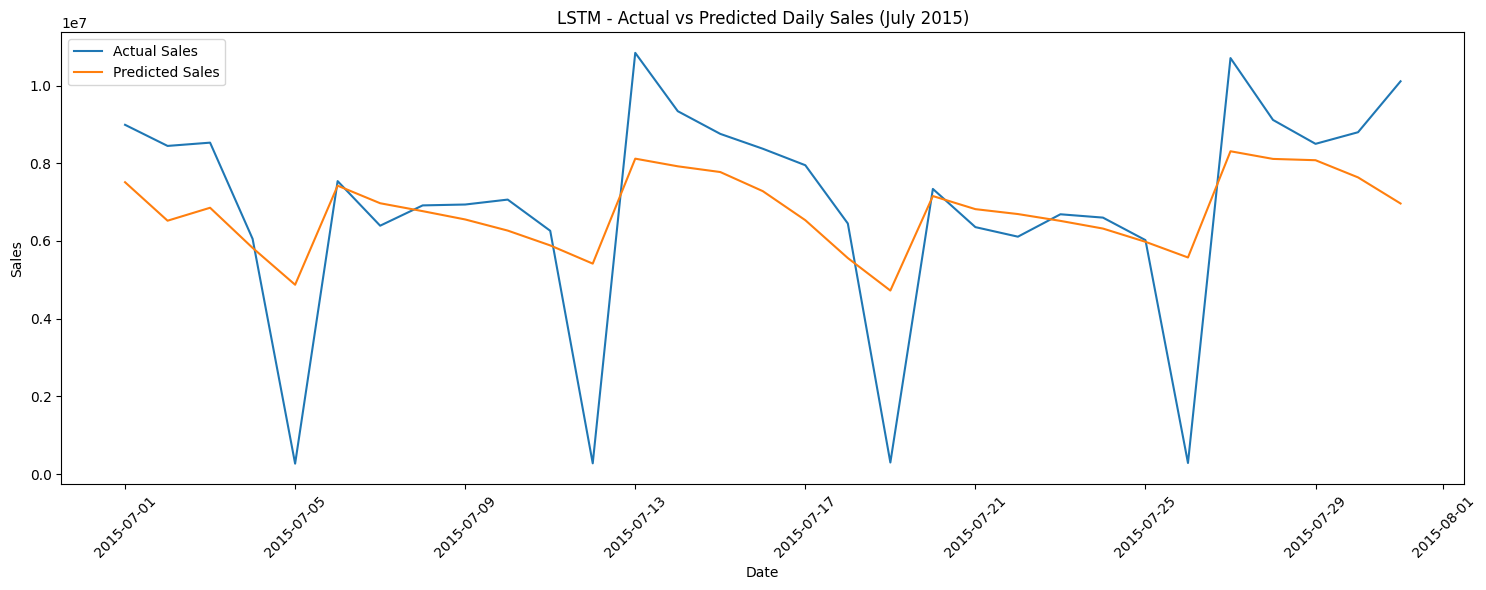

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    lstm_comparison['Date'],
    lstm_comparison['Actual_Sales'],
    label='Actual Sales'
)

plt.plot(
    lstm_comparison['Date'],
    lstm_comparison['Predicted_Sales'],
    label='Predicted Sales'
)

plt.title("LSTM - Actual vs Predicted Daily Sales (July 2015)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Why the Multivariate LSTM Was Added

The univariate LSTM used only historical Sales and tended to overpredict very low Sunday values because it had no direct information about store availability. The improved model adds `OpenStores` and `DayOfWeek`, allowing the network to learn operational and weekly-seasonality signals.

The multivariate model is evaluated on **daily aggregate Sales**, so its metrics should not be directly compared numerically with the store-day Random Forest metrics.

## Improved Multivariate LSTM


In [ ]:
# Create daily multivariate features for the improved LSTM

daily_multivariate = (
    df.groupby('Date')
      .agg(
          Sales=('Sales', 'sum'),
          OpenStores=('Open', 'sum'),
          DayOfWeek=('DayOfWeek', 'first')
      )
      .reset_index()
      .sort_values('Date')
)

# Display basic information
print("Shape:", daily_multivariate.shape)
print("\nColumns:")
print(daily_multivariate.columns.tolist())

print("\nFirst 10 rows:")
print(daily_multivariate.head(10).to_string(index=False))

print("\nLast 5 rows:")
print(daily_multivariate.tail(5).to_string(index=False))

Shape: (942, 4)

Columns:
['Date', 'Sales', 'OpenStores', 'DayOfWeek']

First 10 rows:
      Date    Sales  OpenStores  DayOfWeek
2013-01-01    97235          17          2
2013-01-02  6949829        1111          3
2013-01-03  6347820        1109          4
2013-01-04  6638954        1108          5
2013-01-05  5951593        1107          6
2013-01-06   143904          19          7
2013-01-07 10826848        1106          1
2013-01-08  8749437        1105          2
2013-01-09  7746603        1105          3
2013-01-10  7751485        1105          4

Last 5 rows:
      Date    Sales  OpenStores  DayOfWeek
2015-07-27 10707292        1113          1
2015-07-28  9115073        1113          2
2015-07-29  8499962        1113          3
2015-07-30  8798854        1113          4
2015-07-31 10109742        1113          5


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# --------------------------------------------------
# 1. Split the daily multivariate data chronologically
# --------------------------------------------------

train_multi = daily_multivariate[
    daily_multivariate['Date'] < '2015-07-01'
].copy()

validation_multi = daily_multivariate[
    daily_multivariate['Date'] >= '2015-07-01'
].copy()

print("Training days:", len(train_multi))
print("Validation days:", len(validation_multi))


# --------------------------------------------------
# 2. Define input features and target
# --------------------------------------------------

multi_features = [
    'Sales',
    'OpenStores',
    'DayOfWeek'
]

target_feature = 'Sales'


# --------------------------------------------------
# 3. Create separate scalers
# --------------------------------------------------

X_multi_scaler = MinMaxScaler(feature_range=(-1, 1))
y_multi_scaler = MinMaxScaler(feature_range=(-1, 1))


# --------------------------------------------------
# 4. Fit scalers ONLY on training data
# --------------------------------------------------

X_multi_scaler.fit(
    train_multi[multi_features]
)

y_multi_scaler.fit(
    train_multi[[target_feature]]
)


# --------------------------------------------------
# 5. Transform training and validation data
# --------------------------------------------------

train_multi_scaled = X_multi_scaler.transform(
    train_multi[multi_features]
)

validation_multi_scaled = X_multi_scaler.transform(
    validation_multi[multi_features]
)

train_multi_y_scaled = y_multi_scaler.transform(
    train_multi[[target_feature]]
).flatten()

validation_multi_y_scaled = y_multi_scaler.transform(
    validation_multi[[target_feature]]
).flatten()


# --------------------------------------------------
# 6. Create 28-day multivariate sequences
# --------------------------------------------------

def create_multivariate_sequences(X_data, y_data, window_size):
    X_sequences = []
    y_sequences = []

    for i in range(len(X_data) - window_size):
        X_sequences.append(
            X_data[i:i + window_size]
        )
        y_sequences.append(
            y_data[i + window_size]
        )

    return np.array(X_sequences), np.array(y_sequences)


window_size = 28


# Training sequences
X_multi_train, y_multi_train = create_multivariate_sequences(
    train_multi_scaled,
    train_multi_y_scaled,
    window_size
)


# --------------------------------------------------
# 7. Validation sequences
# Include the last 28 training days as context
# --------------------------------------------------

validation_context_X = np.concatenate([
    train_multi_scaled[-window_size:],
    validation_multi_scaled
])

validation_context_y = np.concatenate([
    train_multi_y_scaled[-window_size:],
    validation_multi_y_scaled
])

X_multi_val, y_multi_val = create_multivariate_sequences(
    validation_context_X,
    validation_context_y,
    window_size
)


# --------------------------------------------------
# 8. Display results
# --------------------------------------------------

print("\nSequence shapes:")
print("X_multi_train:", X_multi_train.shape)
print("y_multi_train:", y_multi_train.shape)
print("X_multi_val:", X_multi_val.shape)
print("y_multi_val:", y_multi_val.shape)

print("\nTraining input scaled range:",
      X_multi_train.min(),
      "to",
      X_multi_train.max())

print("Training target scaled range:",
      y_multi_train.min(),
      "to",
      y_multi_train.max())

Training days: 911
Validation days: 31

Sequence shapes:
X_multi_train: (883, 28, 3)
y_multi_train: (883,)
X_multi_val: (31, 28, 3)
y_multi_val: (31,)

Training input scaled range: -1.0 to 1.0000000000000002
Training target scaled range: -0.997311274093212 to 1.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# Build improved multivariate LSTM
lstm_multi_model = Sequential([
    Input(shape=(28, 3)),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

# Compile model
lstm_multi_model.compile(
    optimizer='adam',
    loss='mse'
)

# Display architecture
lstm_multi_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping
early_stopping_multi = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the improved multivariate LSTM
history_multi = lstm_multi_model.fit(
    X_multi_train,
    y_multi_train,
    validation_data=(
        X_multi_val,
        y_multi_val
    ),
    epochs=30,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_multi],
    verbose=1
)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.1713 - val_loss: 0.1338
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1448 - val_loss: 0.1202
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1346 - val_loss: 0.1060
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1227 - val_loss: 0.0894
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1126 - val_loss: 0.0759
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1027 - val_loss: 0.0567
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0892 - val_loss: 0.0380
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0793 - val_loss: 0.0321
Epoch 9/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0711 - val_loss: 0.0273
Epoch 10/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0665 - val_loss: 0.0249
Epoch 11/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0674 - val_loss: 0.0210
Epoch 12/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0

In [ ]:
print("Epochs completed:", len(history_multi.history['loss']))

print("Best validation loss:",
      min(history_multi.history['val_loss']))

print("Best epoch:",
      history_multi.history['val_loss'].index(
          min(history_multi.history['val_loss'])
      ) + 1)

Epochs completed: 26
Best validation loss: 0.007428403943777084
Best epoch: 21


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on July validation data
lstm_multi_val_predictions_scaled = lstm_multi_model.predict(
    X_multi_val,
    verbose=0
)

# Convert predictions back to actual Sales values
lstm_multi_val_predictions = y_multi_scaler.inverse_transform(
    lstm_multi_val_predictions_scaled
).flatten()

# Convert actual validation targets back to actual Sales values
lstm_multi_val_actual = y_multi_scaler.inverse_transform(
    y_multi_val.reshape(-1, 1)
).flatten()

# Calculate metrics
lstm_multi_mae = mean_absolute_error(
    lstm_multi_val_actual,
    lstm_multi_val_predictions
)

lstm_multi_rmse = np.sqrt(
    mean_squared_error(
        lstm_multi_val_actual,
        lstm_multi_val_predictions
    )
)

lstm_multi_r2 = r2_score(
    lstm_multi_val_actual,
    lstm_multi_val_predictions
)

print("Improved Multivariate LSTM - Validation Results")
print("-----------------------------------------------")
print(f"MAE  : {lstm_multi_mae:.2f}")
print(f"RMSE : {lstm_multi_rmse:.2f}")
print(f"R²   : {lstm_multi_r2:.4f}")

Improved Multivariate LSTM - Validation Results
-----------------------------------------------
MAE  : 504875.09
RMSE : 669092.44
R²   : 0.9451


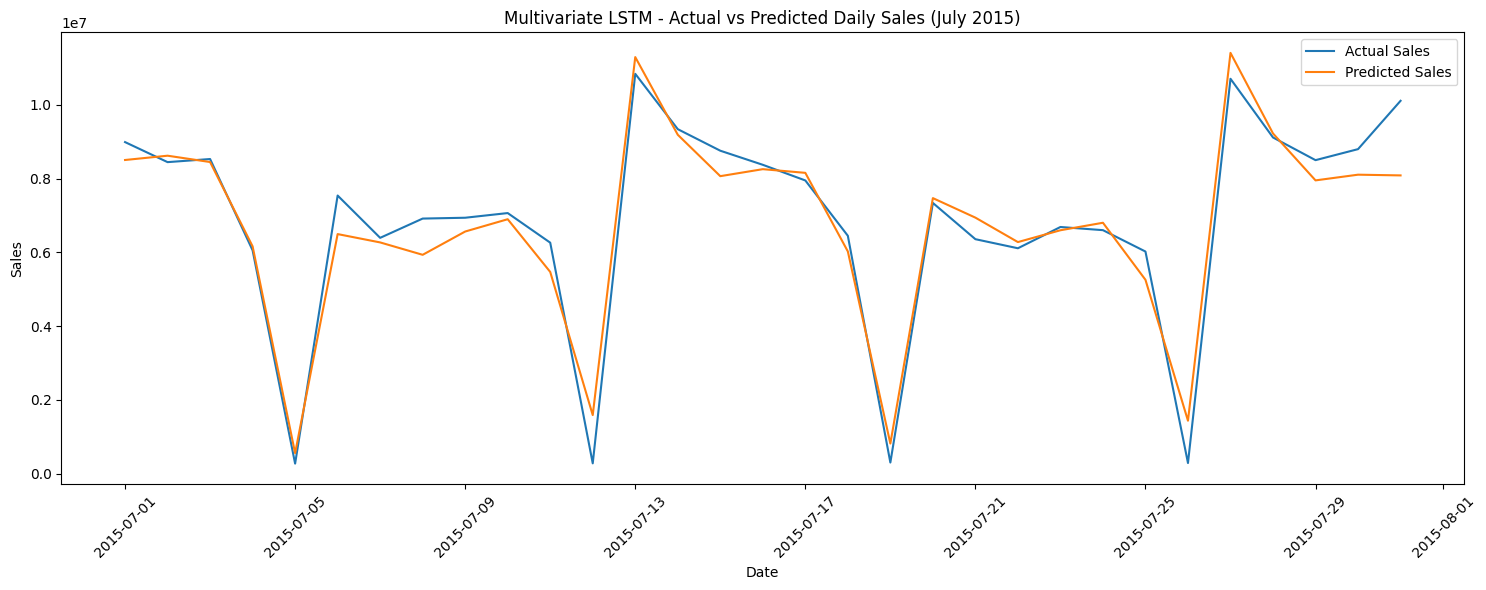

In [ ]:
import matplotlib.pyplot as plt

# Create comparison table
lstm_multi_comparison = pd.DataFrame({
    'Date': validation_multi['Date'].values,
    'Actual_Sales': lstm_multi_val_actual,
    'Predicted_Sales': lstm_multi_val_predictions
})

# Plot actual vs predicted Sales
plt.figure(figsize=(15, 6))

plt.plot(
    lstm_multi_comparison['Date'],
    lstm_multi_comparison['Actual_Sales'],
    label='Actual Sales'
)

plt.plot(
    lstm_multi_comparison['Date'],
    lstm_multi_comparison['Predicted_Sales'],
    label='Predicted Sales'
)

plt.title("Multivariate LSTM - Actual vs Predicted Daily Sales (July 2015)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## LSTM Model & Scaler Serialization


In [ ]:
import os
import joblib
from datetime import datetime

# Create timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create model directory
os.makedirs("../models", exist_ok=True)

# File paths
lstm_model_path = (
    f"../models/rossmann_multivariate_lstm_{timestamp}.keras"
)

x_scaler_path = (
    f"../models/rossmann_lstm_input_scaler_{timestamp}.joblib"
)

y_scaler_path = (
    f"../models/rossmann_lstm_sales_scaler_{timestamp}.joblib"
)

# Save trained LSTM model
lstm_multi_model.save(lstm_model_path)

# Save input feature scaler
joblib.dump(
    X_multi_scaler,
    x_scaler_path
)

# Save Sales target scaler
joblib.dump(
    y_multi_scaler,
    y_scaler_path
)

print("LSTM model saved:")
print(lstm_model_path)

print("\nInput scaler saved:")
print(x_scaler_path)

print("\nSales scaler saved:")
print(y_scaler_path)

print("\nFiles created successfully:")
print(os.listdir("rossmann_models"))

LSTM model saved:
rossmann_models/rossmann_multivariate_lstm_20260909_095057.keras

Input scaler saved:
rossmann_models/rossmann_lstm_input_scaler_20260909_095057.joblib

Sales scaler saved:
rossmann_models/rossmann_lstm_sales_scaler_20260909_095057.joblib

Files created successfully:
['rossmann_multivariate_lstm_20260909_095057.keras', 'rossmann_lstm_input_scaler_20260909_095057.joblib', 'rossmann_lstm_sales_scaler_20260909_095057.joblib']


## Notebook 4 Conclusion

The multivariate LSTM improved July 2015 daily validation performance to approximately:

- **MAE:** 504,875.09
- **RMSE:** 669,092.44
- **R²:** 0.9451

It captured the weekly pattern and Sunday troughs more effectively than the univariate Sales-only LSTM because `OpenStores` and `DayOfWeek` provide operational and calendar context.

**Comparability note:** These LSTM metrics are for daily aggregate Sales, while the Random Forest Sales model is evaluated at store-day level. They are therefore not a direct head-to-head metric comparison.

The trained multivariate LSTM and both scalers were serialized with timestamps for downstream reuse.

# LSTM Time-Series Summary

## Stationarity decision
The Augmented Dickey-Fuller test was used before sequence modelling. The observed p-value was below 0.05, so the null hypothesis of a unit root was rejected. First-order differencing was therefore not required for this series.

## Sequence design
ACF/PACF analysis showed strong weekly structure around seven-day lags. A 28-day sliding window was selected to provide approximately four weekly cycles to the LSTM.

## Model comparison
The univariate LSTM used only historical Sales. The improved multivariate LSTM additionally used OpenStores and DayOfWeek, allowing the sequence model to represent weekly operating patterns and the large Sunday troughs observed in the data.

The RF and LSTM metrics should not be treated as directly comparable accuracy scores because the RF operates at store-day level while the LSTM operates on daily aggregate Sales.
